<a href="https://colab.research.google.com/github/cesa3/nn-ga/blob/main/NN_%2BGA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, precision_score, recall_score
import time

In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adityakadiwal/water-potability")

print("Path to dataset files:", path)

Path to dataset files: /Users/caesar/.cache/kagglehub/datasets/adityakadiwal/water-potability/versions/3


In [12]:
import pandas as pd

path = kagglehub.dataset_download("adityakadiwal/water-potability")
df = pd.read_csv(f"{path}/water_potability.csv")

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\n--- Missing values ---")
print(df.isnull().sum())
print(f"\n--- Target distribution ---")
print(df["Potability"].value_counts())
print(f"  Imbalance ratio: {df['Potability'].mean():.2%} positive")
print(f"\n--- Stats ---")
print(df.describe().round(3).to_string())

Shape: (3276, 10)

Columns: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']

--- Missing values ---
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

--- Target distribution ---
Potability
0    1998
1    1278
Name: count, dtype: int64
  Imbalance ratio: 39.01% positive

--- Stats ---
             ph  Hardness     Solids  Chloramines   Sulfate  Conductivity  Organic_carbon  Trihalomethanes  Turbidity  Potability
count  2785.000  3276.000   3276.000     3276.000  2495.000      3276.000        3276.000         3114.000   3276.000    3276.000
mean      7.081   196.369  22014.093        7.122   333.776       426.205          14.285           66.396      3.967       0.390
std       1.594    32.880   8768.571        

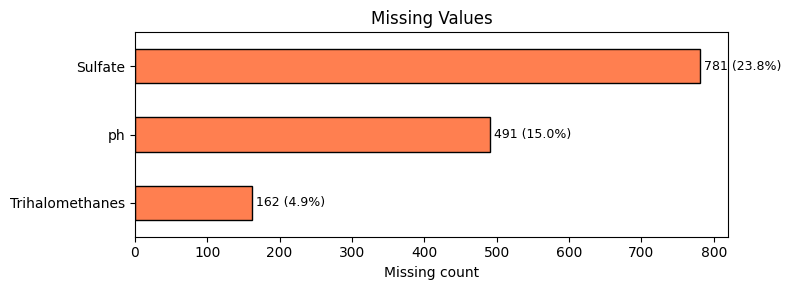

In [13]:

# Missing value bar chart
fig, ax = plt.subplots(figsize=(8, 3))
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=True)
missing.plot.barh(ax=ax, color="coral", edgecolor="black")
ax.set_xlabel("Missing count")
ax.set_title("Missing Values")
for i, (col, val) in enumerate(missing.items()):
    ax.text(val + 5, i, f"{val} ({val/len(df)*100:.1f}%)", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# Data Cleaning
# ============================================================
# Strategy: impute median grouped by Potability (preserves class signal)
# ph, Sulfate, Trihalomethanes have missing values

print(f"Before cleaning: {df.shape}")
print(f"Missing:\n{df.isnull().sum()[df.isnull().sum() > 0]}\n")

# Impute missing values with median per class
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col] = df.groupby("Potability")[col].transform(
            lambda x: x.fillna(x.median())
        )

print(f"After imputation: {df.shape}")
print(f"Missing remaining: {df.isnull().sum().sum()}")

# Split features / target
X = df.drop("Potability", axis=1).values
y = df["Potability"].values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

N_FEATURES = X_train.shape[1]
print(f"\nFeatures: {N_FEATURES}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Train pos rate: {y_train.mean():.2%} | Test pos rate: {y_test.mean():.2%}")

Before cleaning: (3276, 10)
Missing:
ph                 491
Sulfate            781
Trihalomethanes    162
dtype: int64

After imputation: (3276, 10)
Missing remaining: 0

Features: 9
Train: (2620, 9) | Test: (656, 9)
Train pos rate: 39.01% | Test pos rate: 39.02%


In [19]:
# ============================================================
# Water Potability — NN + BB vs GA comparison
# Architecture: 9 → 16 → 1  (177 weights)
# ============================================================
import time
from sklearn.metrics import f1_score, precision_score, recall_score

SEED = 42
N_FEATURES = X_train.shape[1]  # 9

# Smaller architecture: less overfitting with 2620 training samples
H1 = 16
# W1: 9x16 + b1:16 = 160
# W2: 16x1 + b2:1  = 17
# Total = 177
N_WEIGHTS = (N_FEATURES * H1 + H1) + (H1 * 1 + 1)
LAYER_BOUNDARIES = [0, 160, N_WEIGHTS]

np.random.seed(SEED)
print(f"Architecture: {N_FEATURES} -> {H1} -> 1")
print(f"Total weights: {N_WEIGHTS}")
print(f"Layer boundaries: {LAYER_BOUNDARIES}")

def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def unpack_weights(w):
    idx = 0
    W1 = w[idx:idx + N_FEATURES * H1].reshape(N_FEATURES, H1); idx += N_FEATURES * H1
    b1 = w[idx:idx + H1];                                      idx += H1
    W2 = w[idx:idx + H1].reshape(H1, 1);                       idx += H1
    b2 = w[idx:idx + 1]
    return W1, b1, W2, b2

def nn_forward(X, w):
    W1, b1, W2, b2 = unpack_weights(w)
    h1 = relu(X @ W1 + b1)
    return sigmoid(h1 @ W2 + b2).flatten()

def compute_loss(w, X, y):
    p = np.clip(nn_forward(X, w), 1e-9, 1 - 1e-9)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def compute_acc(w, X, y):
    return np.mean((nn_forward(X, w) >= 0.5) == y)

def compute_f1(w, X, y):
    pred = (nn_forward(X, w) >= 0.5).astype(int)
    return f1_score(y, pred, zero_division=0)

def eval_all(w, X, y, label=""):
    pred = (nn_forward(X, w) >= 0.5).astype(int)
    acc = np.mean(pred == y)
    f1 = f1_score(y, pred, zero_division=0)
    prec = precision_score(y, pred, zero_division=0)
    rec = recall_score(y, pred, zero_division=0)
    loss = compute_loss(w, X, y)
    return {"acc": acc, "f1": f1, "prec": prec, "rec": rec, "loss": loss}

print("NN ready.")


Architecture: 9 -> 16 -> 1
Total weights: 177
Layer boundaries: [0, 160, 177]
NN ready.


In [22]:
# ============================================================
# Backprop (BB) — Adam baseline with class weighting
# ============================================================
def run_backprop(seed=SEED, max_iter=1000):
    t0 = time.time()
    mlp = MLPClassifier(
        hidden_layer_sizes=(H1,),
        activation="relu",
        solver="adam",
        learning_rate_init=0.001,
        max_iter=max_iter,
        random_state=seed,
    )
    # Weight positive class higher so BB doesn't collapse to "predict all 0"
    w_pos = (y_train == 0).sum() / (y_train == 1).sum()  # ~1.56
    sample_w = np.where(y_train == 1, w_pos, 1.0)
    mlp.fit(X_train, y_train, sample_weight=sample_w)
    elapsed = time.time() - t0
    pred_test = mlp.predict(X_test)
    pred_train = mlp.predict(X_train)
    return {
        "train_acc": np.mean(pred_train == y_train),
        "test_acc": np.mean(pred_test == y_test),
        "test_f1": f1_score(y_test, pred_test, zero_division=0),
        "test_prec": precision_score(y_test, pred_test, zero_division=0),
        "test_rec": recall_score(y_test, pred_test, zero_division=0),
        "time": elapsed,
        "loss_curve": mlp.loss_curve_,
    }

bb = run_backprop()
print(f"[Backprop] Acc: {bb['test_acc']:.4f} | F1: {bb['test_f1']:.4f} | "
      f"Prec: {bb['test_prec']:.4f} | Rec: {bb['test_rec']:.4f} | Time: {bb['time']:.2f}s")


[Backprop] Acc: 0.6463 | F1: 0.5504 | Prec: 0.5462 | Rec: 0.5547 | Time: 0.34s


In [23]:
# ============================================================
# Rule-based: Decision Tree + XGBoost baselines
# ============================================================
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

def run_decision_tree(seed=SEED, max_depth=10):
    t0 = time.time()
    dt = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_leaf=5,
        random_state=seed,
    )
    dt.fit(X_train, y_train)
    elapsed = time.time() - t0
    pred_test = dt.predict(X_test)
    pred_train = dt.predict(X_train)
    return {
        "train_acc": np.mean(pred_train == y_train),
        "test_acc": np.mean(pred_test == y_test),
        "test_f1": f1_score(y_test, pred_test, zero_division=0),
        "test_prec": precision_score(y_test, pred_test, zero_division=0),
        "test_rec": recall_score(y_test, pred_test, zero_division=0),
        "time": elapsed,
    }

def run_xgboost(seed=SEED, n_estimators=300, max_depth=6, learning_rate=0.05):
    t0 = time.time()
    spw = (y_train == 0).sum() / (y_train == 1).sum()
    xgb = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        scale_pos_weight=spw,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=seed,
        eval_metric="logloss",
    )
    xgb.fit(X_train, y_train)
    elapsed = time.time() - t0
    pred_test = xgb.predict(X_test)
    pred_train = xgb.predict(X_train)
    return {
        "train_acc": np.mean(pred_train == y_train),
        "test_acc": np.mean(pred_test == y_test),
        "test_f1": f1_score(y_test, pred_test, zero_division=0),
        "test_prec": precision_score(y_test, pred_test, zero_division=0),
        "test_rec": recall_score(y_test, pred_test, zero_division=0),
        "time": elapsed,
    }

dt = run_decision_tree()
xgb = run_xgboost()
print(f"[Decision Tree] Acc: {dt['test_acc']:.4f} | F1: {dt['test_f1']:.4f} | "
      f"Prec: {dt['test_prec']:.4f} | Rec: {dt['test_rec']:.4f} | Time: {dt['time']:.4f}s")
print(f"[XGBoost]      Acc: {xgb['test_acc']:.4f} | F1: {xgb['test_f1']:.4f} | "
      f"Prec: {xgb['test_prec']:.4f} | Rec: {xgb['test_rec']:.4f} | Time: {xgb['time']:.4f}s")


[Decision Tree] Acc: 0.7683 | F1: 0.6780 | Prec: 0.7407 | Rec: 0.6250 | Time: 0.0118s
[XGBoost]      Acc: 0.7927 | F1: 0.7178 | Prec: 0.7655 | Rec: 0.6758 | Time: 0.4689s


In [24]:
# ============================================================
# Standard GA — Epoch-based with mini-batch evaluation
# ============================================================
def epoch_ga(X_tr, y_tr, X_te, y_te,
             pop_size=120, epochs=400, batch_size=256,
             mutation_rate=0.1, seed=SEED):
    np.random.seed(seed)
    n = len(X_tr)
    pop = np.random.randn(pop_size, N_WEIGHTS) * 0.1

    best_w, best_loss = None, np.inf
    hist_train, hist_test, hist_loss, hist_f1 = [], [], [], []
    start = time.time()

    for epoch in range(epochs):
        idx_batch = np.random.choice(n, batch_size, replace=False)
        Xb, yb = X_tr[idx_batch], y_tr[idx_batch]

        losses = np.array([compute_loss(ind, Xb, yb) for ind in pop])
        idx_b = np.argmin(losses)

        if losses[idx_b] < best_loss:
            best_loss = losses[idx_b]
            best_w = pop[idx_b].copy()

        hist_loss.append(compute_loss(best_w, X_tr, y_tr))
        hist_train.append(compute_acc(best_w, X_tr, y_tr))
        hist_test.append(compute_acc(best_w, X_te, y_te))
        hist_f1.append(compute_f1(best_w, X_te, y_te))

        alpha_t = 0.5 * (0.01 / 0.5) ** (epoch / epochs)
        fitness = -losses

        def tournament():
            idx = np.random.choice(pop_size, 5, replace=False)
            return pop[idx[np.argmax(fitness[idx])]]

        new_pop = [best_w.copy()]
        while len(new_pop) < pop_size:
            p1, p2 = tournament(), tournament()
            child = p1.copy()
            for li in range(len(LAYER_BOUNDARIES) - 1):
                if np.random.rand() < 0.5:
                    s, e = LAYER_BOUNDARIES[li], LAYER_BOUNDARIES[li + 1]
                    child[s:e] = p2[s:e]
            mask = np.random.rand(N_WEIGHTS) < mutation_rate
            child[mask] += np.random.randn(mask.sum()) * alpha_t
            new_pop.append(child)
        pop = np.array(new_pop)

        if (epoch + 1) % 100 == 0:
            print(f"  Epoch {epoch+1:3d} | Loss: {hist_loss[-1]:.4f} | "
                  f"Train: {hist_train[-1]:.4f} | Test: {hist_test[-1]:.4f} | F1: {hist_f1[-1]:.4f}")

    elapsed = time.time() - start
    return {"w": best_w, "train": hist_train, "test": hist_test,
            "loss": hist_loss, "f1": hist_f1, "time": elapsed}

print("Running Standard GA (epoch-based)...")
ga = epoch_ga(X_train, y_train, X_test, y_test)
m = eval_all(ga["w"], X_test, y_test)
print(f"[GA] Acc: {m['acc']:.4f} | F1: {m['f1']:.4f} | Prec: {m['prec']:.4f} | Rec: {m['rec']:.4f} | Time: {ga['time']:.1f}s")

Running Standard GA (epoch-based)...
  Epoch 100 | Loss: 0.6690 | Train: 0.6359 | Test: 0.6250 | F1: 0.1854
  Epoch 200 | Loss: 0.6164 | Train: 0.6615 | Test: 0.6723 | F1: 0.4638
  Epoch 300 | Loss: 0.6050 | Train: 0.6756 | Test: 0.6646 | F1: 0.3989
  Epoch 400 | Loss: 0.5967 | Train: 0.6756 | Test: 0.6585 | F1: 0.3978
[GA] Acc: 0.6585 | F1: 0.3978 | Prec: 0.6379 | Rec: 0.2891 | Time: 2.4s


In [25]:
# ============================================================
# LAME v2 — Lifespan-Aware Memory Evolution (epoch-based)
# ============================================================
def lame_v2(X_tr, y_tr, X_te, y_te,
            pop_size=120, epochs=400, batch_size=256,
            age_threshold=15, alpha=0.6, beta=0.2,
            seed=SEED):
    np.random.seed(seed)
    n = len(X_tr)
    pop = np.random.randn(pop_size, N_WEIGHTS) * 0.1
    ages = np.zeros((pop_size, N_WEIGHTS), dtype=int)
    prev_losses = np.full(pop_size, np.inf)

    best_w, best_loss = None, np.inf
    hist_train, hist_test, hist_loss, hist_f1 = [], [], [], []
    repair_counts = []
    start = time.time()

    for epoch in range(epochs):
        idx_batch = np.random.choice(n, batch_size, replace=False)
        Xb, yb = X_tr[idx_batch], y_tr[idx_batch]

        losses = np.array([compute_loss(ind, Xb, yb) for ind in pop])
        idx_b = np.argmin(losses)

        if losses[idx_b] < best_loss:
            best_loss = losses[idx_b]
            best_w = pop[idx_b].copy()

        hist_loss.append(compute_loss(best_w, X_tr, y_tr))
        hist_train.append(compute_acc(best_w, X_tr, y_tr))
        hist_test.append(compute_acc(best_w, X_te, y_te))
        hist_f1.append(compute_f1(best_w, X_te, y_te))

        # Per-individual aging
        improved = losses < prev_losses
        for i in range(pop_size):
            if improved[i]:
                ages[i] = np.maximum(0, ages[i] - 2)
            else:
                ages[i] += 1
        prev_losses = losses.copy()

        # Population signal
        top_k = max(5, pop_size // 4)
        top_idx = np.argsort(losses)[:top_k]
        top_mean = pop[top_idx].mean(axis=0)

        alpha_t = alpha * (0.05 / alpha) ** (epoch / epochs)
        beta_t = beta * (0.5 / beta) ** (epoch / epochs)

        # Population-guided repair
        n_repaired = 0
        for i in range(pop_size):
            old_mask = ages[i] > age_threshold
            if old_mask.sum() == 0:
                continue
            n_repaired += old_mask.sum()
            direction = top_mean - pop[i]
            pop[i, old_mask] += (alpha_t * direction[old_mask]
                                 + beta_t * np.random.randn(old_mask.sum()))
            ages[i, old_mask] = 0
        repair_counts.append(n_repaired)

        # Layer-wise crossover
        fitness = -losses
        def tournament():
            idx = np.random.choice(pop_size, 5, replace=False)
            return pop[idx[np.argmax(fitness[idx])]]

        new_pop = [best_w.copy()]
        new_ages = [np.zeros(N_WEIGHTS, dtype=int)]

        while len(new_pop) < pop_size:
            p1_idx = np.random.choice(top_idx)
            p2_idx = np.random.choice(pop_size)
            p1, p2 = pop[p1_idx], pop[p2_idx]

            child = p1.copy()
            child_ages = ages[p1_idx].copy()

            for li in range(len(LAYER_BOUNDARIES) - 1):
                if np.random.rand() < 0.5:
                    s, e = LAYER_BOUNDARIES[li], LAYER_BOUNDARIES[li + 1]
                    child[s:e] = p2[s:e]
                    child_ages[s:e] = ages[p2_idx, s:e]

            mask = np.random.rand(N_WEIGHTS) < 0.05
            child[mask] += np.random.randn(mask.sum()) * beta_t * 0.5

            new_pop.append(child)
            new_ages.append(child_ages)

        pop = np.array(new_pop)
        ages = np.array(new_ages)

        if (epoch + 1) % 100 == 0:
            print(f"  Epoch {epoch+1:3d} | Loss: {hist_loss[-1]:.4f} | "
                  f"Train: {hist_train[-1]:.4f} | Test: {hist_test[-1]:.4f} | F1: {hist_f1[-1]:.4f} | "
                  f"Repaired: {np.mean(repair_counts[-10:]):.0f}w/epoch")

    elapsed = time.time() - start
    return {"w": best_w, "train": hist_train, "test": hist_test,
            "loss": hist_loss, "f1": hist_f1, "repairs": repair_counts,
            "time": elapsed}

print("Running LAME v2 (epoch-based)...")
lame = lame_v2(X_train, y_train, X_test, y_test)
m = eval_all(lame["w"], X_test, y_test)
print(f"[LAME] Acc: {m['acc']:.4f} | F1: {m['f1']:.4f} | Prec: {m['prec']:.4f} | Rec: {m['rec']:.4f} | Time: {lame['time']:.1f}s")

Running LAME v2 (epoch-based)...
  Epoch 100 | Loss: 0.6836 | Train: 0.6279 | Test: 0.6159 | F1: 0.1429 | Repaired: 0w/epoch
  Epoch 200 | Loss: 0.6298 | Train: 0.6489 | Test: 0.6555 | F1: 0.4515 | Repaired: 0w/epoch
  Epoch 300 | Loss: 0.6166 | Train: 0.6511 | Test: 0.6250 | F1: 0.4306 | Repaired: 0w/epoch
  Epoch 400 | Loss: 0.6166 | Train: 0.6511 | Test: 0.6250 | F1: 0.4306 | Repaired: 0w/epoch
[LAME] Acc: 0.6250 | F1: 0.4306 | Prec: 0.5284 | Rec: 0.3633 | Time: 2.4s


Method                 Acc      F1    Prec  Recall     Time
XGBoost             0.7927  0.7178  0.7655  0.6758  0.4689s
Decision Tree       0.7683  0.6780  0.7407  0.6250  0.0118s
Backprop (Adam)     0.6463  0.5504  0.5462  0.5547    0.34s
Standard GA         0.6585  0.3978  0.6379  0.2891     2.4s
LAME v2             0.6250  0.4306  0.5284  0.3633     2.4s
---------------------------------------------------------------------------
Majority baseline   0.6098  0.0000  0.0000  0.0000


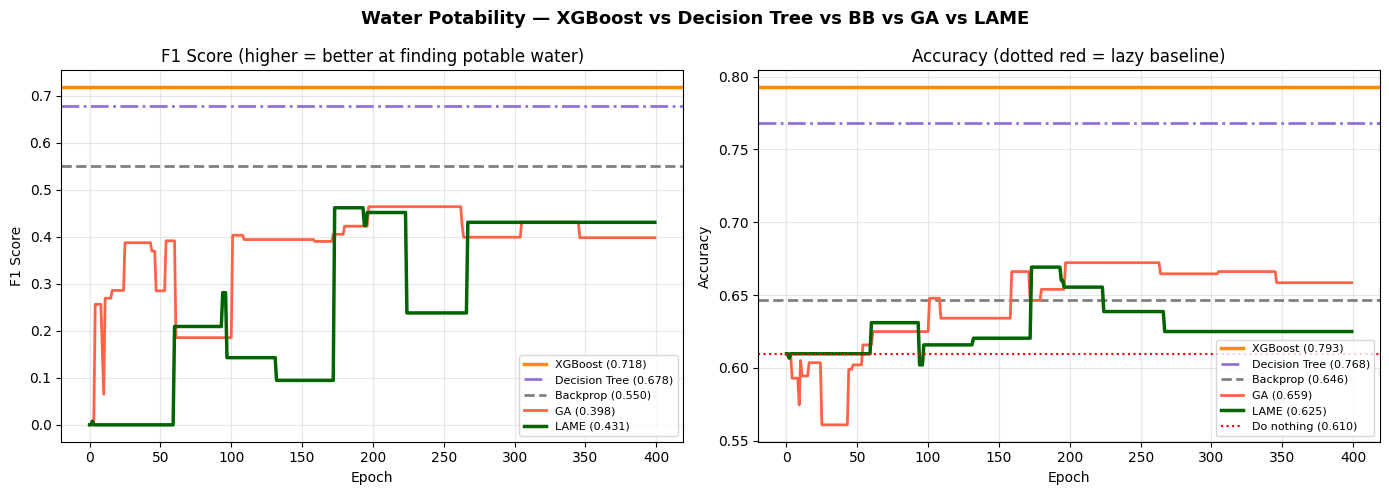


How to read:
- XGBoost, Decision Tree & Backprop = horizontal lines (train once)
- GA & LAME = curves (improve over epochs)
- F1: higher = better at finding potable water
- Accuracy: must beat the red dotted line (61%) to be useful
- XGBoost is boosted trees (ensemble of Decision Trees)
- If XGBoost >> single Decision Tree, ensemble helps
- If NN methods can't beat XGBoost, the NN isn't adding value



In [26]:
# ============================================================
# Results: XGBoost vs Decision Tree vs BB vs GA vs LAME
# ============================================================

bb_m = {"acc": bb["test_acc"], "f1": bb["test_f1"], "prec": bb["test_prec"], "rec": bb["test_rec"]}
dt_m = {"acc": dt["test_acc"], "f1": dt["test_f1"], "prec": dt["test_prec"], "rec": dt["test_rec"]}
xgb_m = {"acc": xgb["test_acc"], "f1": xgb["test_f1"], "prec": xgb["test_prec"], "rec": xgb["test_rec"]}
ga_m = eval_all(ga["w"], X_test, y_test)

la_m = eval_all(lame["w"], X_test, y_test)

print("=" * 75)
print(f"{'Method':<18} {'Acc':>7} {'F1':>7} {'Prec':>7} {'Recall':>7} {'Time':>8}")
print("=" * 75)
print(f"{'XGBoost':<18} {xgb_m['acc']:>7.4f} {xgb_m['f1']:>7.4f} "
      f"{xgb_m['prec']:>7.4f} {xgb_m['rec']:>7.4f} {xgb['time']:>7.4f}s")
print(f"{'Decision Tree':<18} {dt_m['acc']:>7.4f} {dt_m['f1']:>7.4f} "
      f"{dt_m['prec']:>7.4f} {dt_m['rec']:>7.4f} {dt['time']:>7.4f}s")
print(f"{'Backprop (Adam)':<18} {bb_m['acc']:>7.4f} {bb_m['f1']:>7.4f} "
      f"{bb_m['prec']:>7.4f} {bb_m['rec']:>7.4f} {bb['time']:>7.2f}s")
print(f"{'Standard GA':<18} {ga_m['acc']:>7.4f} {ga_m['f1']:>7.4f} "
      f"{ga_m['prec']:>7.4f} {ga_m['rec']:>7.4f} {ga['time']:>7.1f}s")
print(f"{'LAME v2':<18} {la_m['acc']:>7.4f} {la_m['f1']:>7.4f} "
      f"{la_m['prec']:>7.4f} {la_m['rec']:>7.4f} {lame['time']:>7.1f}s")
print("-" * 75)
print(f"{'Majority baseline':<18} {(y_test==0).mean():>7.4f} {'0.0000':>7} "
      f"{'0.0000':>7} {'0.0000':>7}")
print("=" * 75)

# --- 2 key plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Water Potability — XGBoost vs Decision Tree vs BB vs GA vs LAME",
             fontsize=13, fontweight="bold")

# PLOT 1: F1 Score over epochs
ax = axes[0]
ax.axhline(xgb["test_f1"], color="darkorange", linewidth=2.5, linestyle="-",
           label=f"XGBoost ({xgb['test_f1']:.3f})")
ax.axhline(dt["test_f1"], color="mediumpurple", linewidth=2, linestyle="-.",
           label=f"Decision Tree ({dt['test_f1']:.3f})")
ax.axhline(bb["test_f1"], color="gray", linewidth=2, linestyle="--",
           label=f"Backprop ({bb['test_f1']:.3f})")
ax.plot(ga["f1"], color="tomato", linewidth=2, label=f"GA ({ga_m['f1']:.3f})")
ax.plot(lame["f1"], color="darkgreen", linewidth=2.5, label=f"LAME ({la_m['f1']:.3f})")
ax.set_xlabel("Epoch")
ax.set_ylabel("F1 Score")
ax.set_title("F1 Score (higher = better at finding potable water)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# PLOT 2: Test Accuracy over epochs
ax = axes[1]
ax.axhline(xgb["test_acc"], color="darkorange", linewidth=2.5, linestyle="-",
           label=f"XGBoost ({xgb['test_acc']:.3f})")
ax.axhline(dt["test_acc"], color="mediumpurple", linewidth=2, linestyle="-.",
           label=f"Decision Tree ({dt['test_acc']:.3f})")
ax.axhline(bb["test_acc"], color="gray", linewidth=2, linestyle="--",
           label=f"Backprop ({bb['test_acc']:.3f})")
ax.plot(ga["test"], color="tomato", linewidth=2, label=f"GA ({ga_m['acc']:.3f})")
ax.plot(lame["test"], color="darkgreen", linewidth=2.5, label=f"LAME ({la_m['acc']:.3f})")
ax.axhline((y_test == 0).mean(), color="red", linewidth=1.5, linestyle=":",
           label=f"Do nothing ({(y_test==0).mean():.3f})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy (dotted red = lazy baseline)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("""
How to read:
- XGBoost, Decision Tree & Backprop = horizontal lines (train once)
- GA & LAME = curves (improve over epochs)
- F1: higher = better at finding potable water
- Accuracy: must beat the red dotted line (61%) to be useful
- XGBoost is boosted trees (ensemble of Decision Trees)
- If XGBoost >> single Decision Tree, ensemble helps
- If NN methods can't beat XGBoost, the NN isn't adding value
""")
